In [1]:
# Phase 1 - Part 1: Library Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image

print("Phase 1 - Part 1: Libraries successfully imported.")

Phase 1 - Part 1: Libraries successfully imported.


In [2]:
# Phase 1 - Part 2: Data Architecture Verification
print("Phase 1 - Part 2: Verifying Data Architecture\n")

# Define precise paths based on the Kaggle input directory structure
DATASET_PATHS = {
    "Maternal_Health": "/kaggle/input/datasets/csafrit2/maternal-health-risk-data/Maternal Health Risk Data Set.csv",
    "Cardiovascular": "/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv",
    "Skin_Disease_Dir": "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/"
}

for module_name, path in DATASET_PATHS.items():
    if os.path.exists(path):
        print(f"[OK] {module_name} path verified: {path}")
    else:
        print(f"[WARNING] {module_name} path not found: {path}")

print("\nData architecture verification complete. Ready for Phase 2.")

Phase 1 - Part 2: Verifying Data Architecture

[OK] Maternal_Health path verified: /kaggle/input/datasets/csafrit2/maternal-health-risk-data/Maternal Health Risk Data Set.csv
[OK] Cardiovascular path verified: /kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv
[OK] Skin_Disease_Dir path verified: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/

Data architecture verification complete. Ready for Phase 2.


Phase 2: Training Maternal Health Risk Assessor (Module A)

--- Maternal Health Dataset Preview ---


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Dataset Shape: (1014, 7)

Preprocessing Features and Target...
Training Random Forest Classifier for Module A...

Evaluating Model Performance...
Maternal Health Model Accuracy: 80.79%

Classification Report:
              precision    recall  f1-score   support

   high risk       0.96      0.93      0.94        55
    low risk       0.75      0.85      0.80        81
    mid risk       0.76      0.66      0.70        67

    accuracy                           0.81       203
   macro avg       0.82      0.81      0.82       203
weighted avg       0.81      0.81      0.81       203



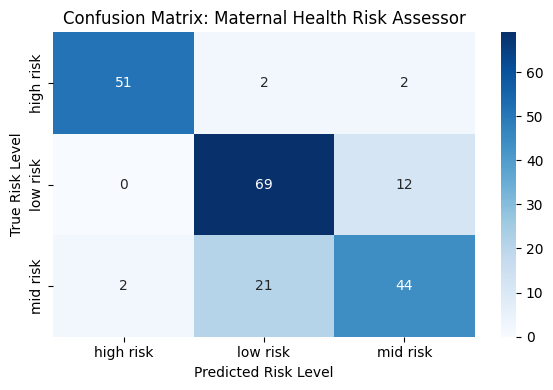


Serializing Model and Encoders to Disk...
Module A artifacts saved successfully. Ready for Phase 3.


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("Phase 2: Training Maternal Health Risk Assessor (Module A)\n")

# --- Step 2.1: Load and Clean Data ---
maternal_path = DATASET_PATHS["Maternal_Health"]
df_maternal = pd.read_csv(maternal_path)

print("--- Maternal Health Dataset Preview ---")
display(df_maternal.head())
print(f"Dataset Shape: {df_maternal.shape}\n")

# Define Features (X) and Target (y)
X_maternal = df_maternal.drop(columns=['RiskLevel'])
y_maternal = df_maternal['RiskLevel']

# --- Step 2.2: Feature Scaling and Label Encoding ---
print("Preprocessing Features and Target...")

# Encode Target Variable (Low, Mid, High Risk)
maternal_label_encoder = LabelEncoder()
y_maternal_encoded = maternal_label_encoder.fit_transform(y_maternal)

# Scale Numerical Features (Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate)
maternal_scaler = StandardScaler()
X_maternal_scaled = maternal_scaler.fit_transform(X_maternal)

# Train/Validation Split
X_train_mat, X_val_mat, y_train_mat, y_val_mat = train_test_split(
    X_maternal_scaled, y_maternal_encoded, test_size=0.20, random_state=42, stratify=y_maternal_encoded
)

# --- Step 2.3: Train the Classifier ---
print("Training Random Forest Classifier for Module A...")
maternal_rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
maternal_rf_model.fit(X_train_mat, y_train_mat)

# --- Step 2.4: Evaluate and Serialize ---
print("\nEvaluating Model Performance...")
y_pred_mat = maternal_rf_model.predict(X_val_mat)

maternal_acc = accuracy_score(y_val_mat, y_pred_mat)
print(f"Maternal Health Model Accuracy: {maternal_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_val_mat, y_pred_mat, target_names=maternal_label_encoder.classes_))

# Visualizing Confusion Matrix
cm_mat = confusion_matrix(y_val_mat, y_pred_mat)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=maternal_label_encoder.classes_, 
            yticklabels=maternal_label_encoder.classes_)
plt.title("Confusion Matrix: Maternal Health Risk Assessor")
plt.xlabel("Predicted Risk Level")
plt.ylabel("True Risk Level")
plt.tight_layout()
plt.show()

# Serialize the Model and Preprocessing Objects
print("\nSerializing Model and Encoders to Disk...")
os.makedirs('/kaggle/working/swasthyasetu_models/module_a', exist_ok=True)

joblib.dump(maternal_rf_model, '/kaggle/working/swasthyasetu_models/module_a/maternal_rf_model.pkl')
joblib.dump(maternal_scaler, '/kaggle/working/swasthyasetu_models/module_a/maternal_scaler.pkl')
joblib.dump(maternal_label_encoder, '/kaggle/working/swasthyasetu_models/module_a/maternal_label_encoder.pkl')

print("Module A artifacts saved successfully. Ready for Phase 3.")

Phase 3: Training Cardiovascular Risk Predictor (Module B)

--- Cardiovascular Dataset Preview ---


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Initial Dataset Shape: (70000, 13)

Handling Blood Pressure Outliers...
Dataset Shape after outlier removal: (68645, 12)

Scaling Numerical Features...
Training Gradient Boosting Classifier for Module B...

Evaluating Model Performance...
Cardiovascular Model Accuracy: 73.98%

Classification Report:
               precision    recall  f1-score   support

  No Risk (0)       0.73      0.78      0.75      6937
High Risk (1)       0.76      0.70      0.73      6792

     accuracy                           0.74     13729
    macro avg       0.74      0.74      0.74     13729
 weighted avg       0.74      0.74      0.74     13729



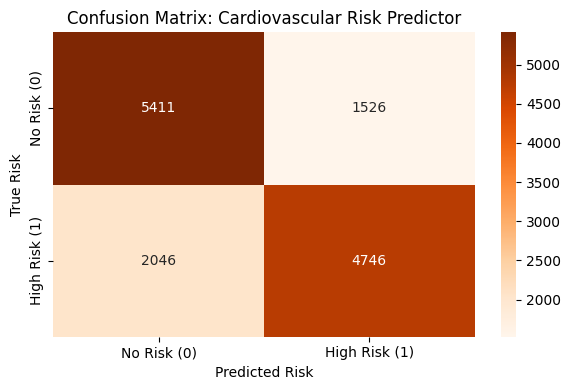


Serializing Model and Scaler to Disk...
Module B artifacts saved successfully. Ready for Phase 4.


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

print("Phase 3: Training Cardiovascular Risk Predictor (Module B)\n")

# --- Step 3.1: Load and Clean Data ---
cardio_path = DATASET_PATHS["Cardiovascular"]
# The cardio_train dataset uses a semicolon separator
df_cardio = pd.read_csv(cardio_path, sep=';')

print("--- Cardiovascular Dataset Preview ---")
display(df_cardio.head())
print(f"Initial Dataset Shape: {df_cardio.shape}\n")

# Drop the 'id' column as it is not a predictive feature
if 'id' in df_cardio.columns:
    df_cardio = df_cardio.drop(columns=['id'])

# Convert age from days to years for better interpretability
df_cardio['age'] = (df_cardio['age'] / 365.25).round().astype(int)

# --- Step 3.2: Handle Outliers and Scale Features ---
print("Handling Blood Pressure Outliers...")

# Filter extreme impossible biological values for blood pressure
df_cardio = df_cardio[
    (df_cardio['ap_hi'] >= 80) & (df_cardio['ap_hi'] <= 250) & 
    (df_cardio['ap_lo'] >= 50) & (df_cardio['ap_lo'] <= 150) &
    (df_cardio['ap_hi'] > df_cardio['ap_lo'])
]

print(f"Dataset Shape after outlier removal: {df_cardio.shape}\n")

# Define Features (X) and Target (y)
X_cardio = df_cardio.drop(columns=['cardio'])
y_cardio = df_cardio['cardio']

print("Scaling Numerical Features...")
cardio_scaler = StandardScaler()
X_cardio_scaled = cardio_scaler.fit_transform(X_cardio)

# Train/Validation Split
X_train_car, X_val_car, y_train_car, y_val_car = train_test_split(
    X_cardio_scaled, y_cardio, test_size=0.20, random_state=42, stratify=y_cardio
)

# --- Step 3.3: Train the Classifier ---
print("Training Gradient Boosting Classifier for Module B...")
cardio_gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
cardio_gb_model.fit(X_train_car, y_train_car)

# --- Step 3.4: Evaluate and Serialize ---
print("\nEvaluating Model Performance...")
y_pred_car = cardio_gb_model.predict(X_val_car)

cardio_acc = accuracy_score(y_val_car, y_pred_car)
print(f"Cardiovascular Model Accuracy: {cardio_acc * 100:.2f}%\n")

target_names_car = ['No Risk (0)', 'High Risk (1)']
print("Classification Report:")
print(classification_report(y_val_car, y_pred_car, target_names=target_names_car))

# Visualizing Confusion Matrix
cm_car = confusion_matrix(y_val_car, y_pred_car)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_car, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names_car, 
            yticklabels=target_names_car)
plt.title("Confusion Matrix: Cardiovascular Risk Predictor")
plt.xlabel("Predicted Risk")
plt.ylabel("True Risk")
plt.tight_layout()
plt.show()

# Serialize the Model and Preprocessing Objects
print("\nSerializing Model and Scaler to Disk...")
os.makedirs('/kaggle/working/swasthyasetu_models/module_b', exist_ok=True)

joblib.dump(cardio_gb_model, '/kaggle/working/swasthyasetu_models/module_b/cardio_gb_model.pkl')
joblib.dump(cardio_scaler, '/kaggle/working/swasthyasetu_models/module_b/cardio_scaler.pkl')

print("Module B artifacts saved successfully. Ready for Phase 4.")

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

print("Phase 4: Training Skin Disease Classifier (Module C)\n")

# --- Step 4.1: Load Metadata and Map Image Paths ---
skin_dir = DATASET_PATHS["Skin_Disease_Dir"]
metadata_path = os.path.join(skin_dir, 'HAM10000_metadata.csv')

print("Loading Metadata and Mapping Image Paths...")
df_skin = pd.read_csv(metadata_path)

# HAM10000 images are typically split across two directories
image_paths = glob.glob(os.path.join(skin_dir, '*', '*.jpg'))
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

# Map the absolute paths to the dataframe
df_skin['path'] = df_skin['image_id'].map(image_path_dict)

# Drop rows where the image file was not found
df_skin = df_skin.dropna(subset=['path'])

print(f"Total valid images mapped: {len(df_skin)}")

# Encode the target variable (7 classes of skin lesions)
skin_label_encoder = LabelEncoder()
df_skin['target'] = skin_label_encoder.fit_transform(df_skin['dx'])

print(f"Skin Disease Classes Found: {list(skin_label_encoder.classes_)}\n")

# --- Step 4.2: Train/Validation Split and DataLoaders ---
# Stratified split to maintain class distribution
train_df, val_df = train_test_split(df_skin, test_size=0.20, random_state=42, stratify=df_skin['target'])

# Define PyTorch Dataset
class SkinDiseaseDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.loc[index, 'path']
        image = Image.open(img_path).convert('RGB')
        label = self.df.loc[index, 'target']
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# Define Image Transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SkinDiseaseDataset(train_df, transform=train_transforms)
val_dataset = SkinDiseaseDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# --- Step 4.3: Initialize Pre-trained CNN ---
print("Initializing Pre-trained MobileNetV2 Architecture...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation Device: {device}")

# Using MobileNetV2 for fast mobile-friendly inference
model_c = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Modify the final classification head for 7 classes
num_classes = len(skin_label_encoder.classes_)
model_c.classifier[1] = nn.Linear(model_c.last_channel, num_classes)
model_c = model_c.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c.parameters(), lr=0.001)

# --- Step 4.4: Training Loop ---
epochs = 3 # Keeping low for hackathon execution speed
print(f"\nCommencing Training for {epochs} Epochs...")

for epoch in range(epochs):
    model_c.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_c(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}] - Training Loss: {running_loss/len(train_loader):.4f}")

# --- Step 4.5: Validation and Serialization ---
print("\nEvaluating Model on Validation Set...")
model_c.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_c(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

cnn_acc = accuracy_score(all_targets, all_preds)
print(f"Skin Disease Model Accuracy: {cnn_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=skin_label_encoder.classes_, zero_division=0))

# Serialize the Model
print("Serializing Model and Encoders to Disk...")
os.makedirs('/kaggle/working/swasthyasetu_models/module_c', exist_ok=True)

# Save the PyTorch state dict
torch.save(model_c.state_dict(), '/kaggle/working/swasthyasetu_models/module_c/skin_disease_mobilenet.pth')
# Save the label encoder
joblib.dump(skin_label_encoder, '/kaggle/working/swasthyasetu_models/module_c/skin_label_encoder.pkl')

print("Module C artifacts saved successfully. Phase 4 complete.")


Phase 4: Training Skin Disease Classifier (Module C)

Loading Metadata and Mapping Image Paths...
Total valid images mapped: 10015
Skin Disease Classes Found: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Initializing Pre-trained MobileNetV2 Architecture...
Computation Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 203MB/s]



Commencing Training for 3 Epochs...
Epoch [1/3] - Training Loss: 0.7719
Epoch [2/3] - Training Loss: 0.6495
Epoch [3/3] - Training Loss: 0.6009

Evaluating Model on Validation Set...
Skin Disease Model Accuracy: 78.48%

Classification Report:
              precision    recall  f1-score   support

       akiec       0.42      0.60      0.50        65
         bcc       0.52      0.82      0.63       103
         bkl       0.56      0.55      0.55       220
          df       0.29      0.09      0.13        23
         mel       0.60      0.40      0.48       223
          nv       0.90      0.91      0.91      1341
        vasc       0.89      0.57      0.70        28

    accuracy                           0.78      2003
   macro avg       0.60      0.56      0.56      2003
weighted avg       0.79      0.78      0.78      2003

Serializing Model and Encoders to Disk...
Module C artifacts saved successfully. Phase 4 complete.


In [6]:
import os
import joblib
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np

print("Phase 5: Unified Inference API Construction (DiagnosticRouter)\n")

class DiagnosticRouter:
    def __init__(self, base_model_path='/kaggle/working/swasthyasetu_models'):
        print("Initializing DiagnosticRouter and loading models into memory...")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Load Module A: Maternal Health
        self.maternal_model = joblib.load(f'{base_model_path}/module_a/maternal_rf_model.pkl')
        self.maternal_scaler = joblib.load(f'{base_model_path}/module_a/maternal_scaler.pkl')
        self.maternal_encoder = joblib.load(f'{base_model_path}/module_a/maternal_label_encoder.pkl')
        
        # Load Module B: Cardiovascular
        self.cardio_model = joblib.load(f'{base_model_path}/module_b/cardio_gb_model.pkl')
        self.cardio_scaler = joblib.load(f'{base_model_path}/module_b/cardio_scaler.pkl')
        
        # Load Module C: Skin Disease (PyTorch)
        self.skin_encoder = joblib.load(f'{base_model_path}/module_c/skin_label_encoder.pkl')
        self.skin_model = self._initialize_skin_model(f'{base_model_path}/module_c/skin_disease_mobilenet.pth')
        self.skin_transforms = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        print("All diagnostic modules successfully loaded and ready for inference.")

    def _initialize_skin_model(self, weight_path):
        model = models.mobilenet_v2(weights=None)
        num_classes = len(self.skin_encoder.classes_)
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)
        model.load_state_dict(torch.load(weight_path, map_location=self.device))
        model.to(self.device)
        model.eval()
        return model

    def evaluate_maternal_risk(self, patient_data):
        df_input = pd.DataFrame([patient_data])
        # Ensure column order matches training
        expected_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
        df_input = df_input[expected_cols]
        
        scaled_input = self.maternal_scaler.transform(df_input)
        probs = self.maternal_model.predict_proba(scaled_input)[0]
        pred_idx = np.argmax(probs)
        pred_class = self.maternal_encoder.inverse_transform([pred_idx])[0]
        
        return {
            "Diagnostic_Module": "Maternal Health Risk",
            "Prediction": pred_class,
            "Confidence": round(probs[pred_idx] * 100, 2),
            "Status": "Success"
        }

    def evaluate_cardiovascular_risk(self, patient_data):
        df_input = pd.DataFrame([patient_data])
        # Ensure column order matches training
        expected_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        df_input = df_input[expected_cols]
        
        scaled_input = self.cardio_scaler.transform(df_input)
        probs = self.cardio_model.predict_proba(scaled_input)[0]
        
        # Index 1 is usually the "Positive/High Risk" class in binary classification
        risk_prob = probs[1]
        prediction = "High Risk" if risk_prob >= 0.5 else "No Risk"
        
        return {
            "Diagnostic_Module": "Cardiovascular Risk",
            "Prediction": prediction,
            "Risk_Probability": round(risk_prob * 100, 2),
            "Status": "Success"
        }

    def evaluate_skin_lesion(self, image_path):
        try:
            image = Image.open(image_path).convert('RGB')
            input_tensor = self.skin_transforms(image).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                outputs = self.skin_model(input_tensor)
                probs = torch.nn.functional.softmax(outputs[0], dim=0)
                pred_idx = torch.argmax(probs).item()
                
            pred_class = self.skin_encoder.inverse_transform([pred_idx])[0]
            confidence = probs[pred_idx].item()
            
            return {
                "Diagnostic_Module": "Skin Disease Classification",
                "Prediction": pred_class,
                "Confidence": round(confidence * 100, 2),
                "Status": "Success"
            }
        except Exception as e:
            return {"Status": "Error", "Message": str(e)}

# Instantiate the router globally for Phase 6 usage
diagnostic_api = DiagnosticRouter()

Phase 5: Unified Inference API Construction (DiagnosticRouter)

Initializing DiagnosticRouter and loading models into memory...
All diagnostic modules successfully loaded and ready for inference.


In [7]:
import time
import json
import random
import glob

print("Phase 6: System Validation and End-to-End Testing\n")

def print_api_response(patient_id, test_type, response, execution_time):
    print(f"--- Diagnostic Report: {patient_id} ---")
    print(f"Test Type: {test_type}")
    print(json.dumps(response, indent=4))
    print(f"Execution Time: {execution_time:.4f} seconds\n")

# --- Test Case 1: Maternal Health Evaluation ---
print("Executing Test Case 1: Maternal Health Routing...")
dummy_maternal_data = {
    'Age': 32,
    'SystolicBP': 140,
    'DiastolicBP': 100,
    'BS': 15.0,
    'BodyTemp': 98.0,
    'HeartRate': 88
}

start_time = time.time()
response_maternal = diagnostic_api.evaluate_maternal_risk(dummy_maternal_data)
exec_time_maternal = time.time() - start_time

print_api_response("Patient_A001", "Maternal Biometrics", response_maternal, exec_time_maternal)


# --- Test Case 2: Cardiovascular Health Evaluation ---
print("Executing Test Case 2: Cardiovascular Health Routing...")
dummy_cardio_data = {
    'age': 58,           
    'gender': 2,         
    'height': 170,
    'weight': 92.0,
    'ap_hi': 155,
    'ap_lo': 95,
    'cholesterol': 3,    
    'gluc': 2,           
    'smoke': 1,
    'alco': 0,
    'active': 0
}

start_time = time.time()
response_cardio = diagnostic_api.evaluate_cardiovascular_risk(dummy_cardio_data)
exec_time_cardio = time.time() - start_time

print_api_response("Patient_B002", "Cardiovascular Biometrics", response_cardio, exec_time_cardio)


# --- Test Case 3: Skin Disease Image Evaluation ---
print("Executing Test Case 3: Skin Disease Computer Vision Routing...")

sample_images = glob.glob(os.path.join(DATASET_PATHS["Skin_Disease_Dir"], '*', '*.jpg'))

if sample_images:
    test_image_path = random.choice(sample_images)
    print(f"Simulating upload for image: {os.path.basename(test_image_path)}")
    
    start_time = time.time()
    response_skin = diagnostic_api.evaluate_skin_lesion(test_image_path)
    exec_time_skin = time.time() - start_time
    
    print_api_response("Patient_C003", "Skin Lesion Image", response_skin, exec_time_skin)
else:
    print("Error: No images found in the specified directory to run Test Case 3.")

print("Phase 6 Validation Complete. The Multi-Model Diagnostic Suite is operational.")

Phase 6: System Validation and End-to-End Testing

Executing Test Case 1: Maternal Health Routing...
--- Diagnostic Report: Patient_A001 ---
Test Type: Maternal Biometrics
{
    "Diagnostic_Module": "Maternal Health Risk",
    "Prediction": "high risk",
    "Confidence": 100.0,
    "Status": "Success"
}
Execution Time: 0.0537 seconds

Executing Test Case 2: Cardiovascular Health Routing...
--- Diagnostic Report: Patient_B002 ---
Test Type: Cardiovascular Biometrics
{
    "Diagnostic_Module": "Cardiovascular Risk",
    "Prediction": "High Risk",
    "Risk_Probability": 86.04,
    "Status": "Success"
}
Execution Time: 0.0035 seconds

Executing Test Case 3: Skin Disease Computer Vision Routing...
Simulating upload for image: ISIC_0029456.jpg
--- Diagnostic Report: Patient_C003 ---
Test Type: Skin Lesion Image
{
    "Diagnostic_Module": "Skin Disease Classification",
    "Prediction": "nv",
    "Confidence": 99.99,
    "Status": "Success"
}
Execution Time: 0.0569 seconds

Phase 6 Validatio

In [8]:
!pip install gradio -q

In [1]:
import gradio as gr
import pandas as pd
import tempfile
import os

print("Phase 7: Launching SwasthyaSetu Interactive Web UI...\n")

# --- Wrapper Functions for Gradio ---

def gradio_maternal(age, sys_bp, dia_bp, bs, temp, hr):
    data = {
        'Age': age, 'SystolicBP': sys_bp, 'DiastolicBP': dia_bp, 
        'BS': bs, 'BodyTemp': temp, 'HeartRate': hr
    }
    result = diagnostic_api.evaluate_maternal_risk(data)
    return f"Prediction: {result['Prediction']}\nConfidence: {result['Confidence']}%"

def gradio_cardio(age, gender, height, weight, ap_hi, ap_lo, chol, gluc, smoke, alco, active):
    # Mapping dropdowns back to numeric categories the model expects
    gender_map = {"Women": 1, "Men": 2}
    chol_gluc_map = {"Normal": 1, "Above Normal": 2, "Well Above Normal": 3}
    binary_map = {"Yes": 1, "No": 0}
    
    data = {
        'age': age,
        'gender': gender_map[gender],
        'height': height,
        'weight': weight,
        'ap_hi': ap_hi,
        'ap_lo': ap_lo,
        'cholesterol': chol_gluc_map[chol],
        'gluc': chol_gluc_map[gluc],
        'smoke': binary_map[smoke],
        'alco': binary_map[alco],
        'active': binary_map[active]
    }
    result = diagnostic_api.evaluate_cardiovascular_risk(data)
    return f"Prediction: {result['Prediction']}\nRisk Probability: {result['Risk_Probability']}%"

def gradio_skin(image):
    if image is None:
        return "Please upload an image."
    
    # Gradio passes a PIL image. We save it to a temp file for our Phase 5 API.
    temp_dir = tempfile.gettempdir()
    temp_path = os.path.join(temp_dir, "temp_skin_img.jpg")
    image.save(temp_path)
    
    result = diagnostic_api.evaluate_skin_lesion(temp_path)
    return f"Prediction: {result['Prediction']}\nConfidence: {result['Confidence']}%"


# --- Building the Gradio Interface ---

with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue")) as swasthya_app:
    gr.Markdown("# 🏥 SwasthyaSetu: Advanced Diagnostic Suite")
    gr.Markdown("Enter patient biometrics or upload medical images to receive instant, AI-driven diagnostic insights.")
    
    with gr.Tabs():
        # Tab 1: Maternal Health
        with gr.TabItem("Maternal Health Risk"):
            with gr.Row():
                with gr.Column():
                    mat_age = gr.Slider(10, 70, value=25, label="Age")
                    mat_sys = gr.Slider(70, 160, value=120, label="Systolic BP")
                    mat_dia = gr.Slider(50, 100, value=80, label="Diastolic BP")
                    mat_bs = gr.Slider(5.0, 20.0, value=7.5, label="Blood Sugar (mmol/L)")
                    mat_temp = gr.Slider(97.0, 104.0, value=98.6, label="Body Temperature (°F)")
                    mat_hr = gr.Slider(50, 120, value=75, label="Heart Rate (bpm)")
                    mat_btn = gr.Button("Analyze Maternal Risk", variant="primary")
                with gr.Column():
                    mat_output = gr.Textbox(label="Diagnostic Report", lines=4)
            mat_btn.click(gradio_maternal, inputs=[mat_age, mat_sys, mat_dia, mat_bs, mat_temp, mat_hr], outputs=mat_output)

        # Tab 2: Cardiovascular Health
        with gr.TabItem("Cardiovascular Risk"):
            with gr.Row():
                with gr.Column():
                    car_age = gr.Slider(20, 100, value=50, label="Age (Years)")
                    car_gen = gr.Radio(["Women", "Men"], value="Men", label="Gender")
                    car_ht = gr.Slider(100, 220, value=170, label="Height (cm)")
                    car_wt = gr.Slider(40, 150, value=75, label="Weight (kg)")
                    car_aphi = gr.Slider(80, 220, value=120, label="Systolic BP (ap_hi)")
                    car_aplo = gr.Slider(50, 150, value=80, label="Diastolic BP (ap_lo)")
                with gr.Column():
                    car_chol = gr.Dropdown(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Cholesterol")
                    car_gluc = gr.Dropdown(["Normal", "Above Normal", "Well Above Normal"], value="Normal", label="Glucose")
                    car_smk = gr.Radio(["Yes", "No"], value="No", label="Smoker")
                    car_alc = gr.Radio(["Yes", "No"], value="No", label="Alcohol Intake")
                    car_act = gr.Radio(["Yes", "No"], value="Yes", label="Physically Active")
                    car_btn = gr.Button("Analyze Cardiovascular Risk", variant="primary")
                    car_output = gr.Textbox(label="Diagnostic Report", lines=4)
            car_btn.click(gradio_cardio, inputs=[car_age, car_gen, car_ht, car_wt, car_aphi, car_aplo, car_chol, car_gluc, car_smk, car_alc, car_act], outputs=car_output)

        # Tab 3: Skin Disease
        with gr.TabItem("Skin Disease Classification"):
            with gr.Row():
                with gr.Column():
                    skin_in = gr.Image(type="pil", label="Upload Skin Lesion Image")
                    skin_btn = gr.Button("Analyze Image", variant="primary")
                with gr.Column():
                    skin_out = gr.Textbox(label="Diagnostic Report", lines=4)
            skin_btn.click(gradio_skin, inputs=[skin_in], outputs=skin_out)

# Launch the app inline in the Kaggle notebook
swasthya_app.launch(share=True, inline=True)

Phase 7: Launching SwasthyaSetu Interactive Web UI...



/tmp/ipykernel_58/1565362413.py:55: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue")) as swasthya_app:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://191986e26afb3661a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
